# Churn Prediction Project

### Let's set up the environment and load the data

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

!wget $data

--2026-03-07 17:16:49--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.4’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.001s  

2026-03-07 17:16:49 (124 MB/s) - ‘course_lead_scoring.csv.4’ saved [80876/80876]



In [38]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [39]:
df.shape


(1462, 9)

Now that we have our data loaded and saved in a df. We also see that columns names have been normalised and look good already.

We do see that there is some missing data at least in column `industry`

### 1. Data preparation

+ Let's have a look at any missing data and which columns contain said missing data
  

In [40]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

Some of the data is missing
+ 8.75 % of `lead_source`
+ 9.17 % of `industry`
+ 12.38 % of `annual_income` (No wonder people wouldn't share that info)
+ 6.84 % of `employment_status`
+ 4.31 % of `location`

The instructions call for us to fill all missing data with either NaN or 0, for categorical and numerical variables respectively.

+ Let's handle categorical columns first 

In [41]:
categorical_cols = list(df.dtypes[df.dtypes == 'str'].index)
categorical_cols

['lead_source', 'industry', 'employment_status', 'location']

In [42]:
for c in categorical_cols:
    df[c] = df[c].fillna('NaN')
df[categorical_cols].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

+ Now let's do the same for numerical columns


In [43]:
numerical_cols = list(df.dtypes[df.dtypes != 'str'].index)
numerical_cols.pop()
numerical_cols

['number_of_courses_viewed',
 'annual_income',
 'interaction_count',
 'lead_score']

In [44]:
for c in numerical_cols:
    df[c] = df[c].fillna(0)
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

+ Now we have **zero** missing data in any of our columns, which we wanted

## Question 1:
What is the most frequent observation (mode) for the column `industry`?

- `NA`
- `technology`
- `healthcare`
- `retail`

In [45]:
df.industry.value_counts()


industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NaN              134
Name: count, dtype: int64

+ So **retail** is our most frequent value in `industry`

#### We will try to utilise a different type of graphical representation to visualize how churn rate changes over specific values in categorical columns

That representation is using **FacetGrid** in seaborn, and allows us to plot churn vs all categorical variables. 
It needs to reshape the df and change it into long formatting.


In [46]:
df_long = df.melt(
    id_vars='converted',
    value_vars=categorical_cols,
    var_name='feature',
    value_name='category'
)
df_long.head()

,converted,feature,category
0,1,lead_source,paid_ads
1,0,lead_source,social_media
2,1,lead_source,events
3,0,lead_source,paid_ads
4,1,lead_source,referral


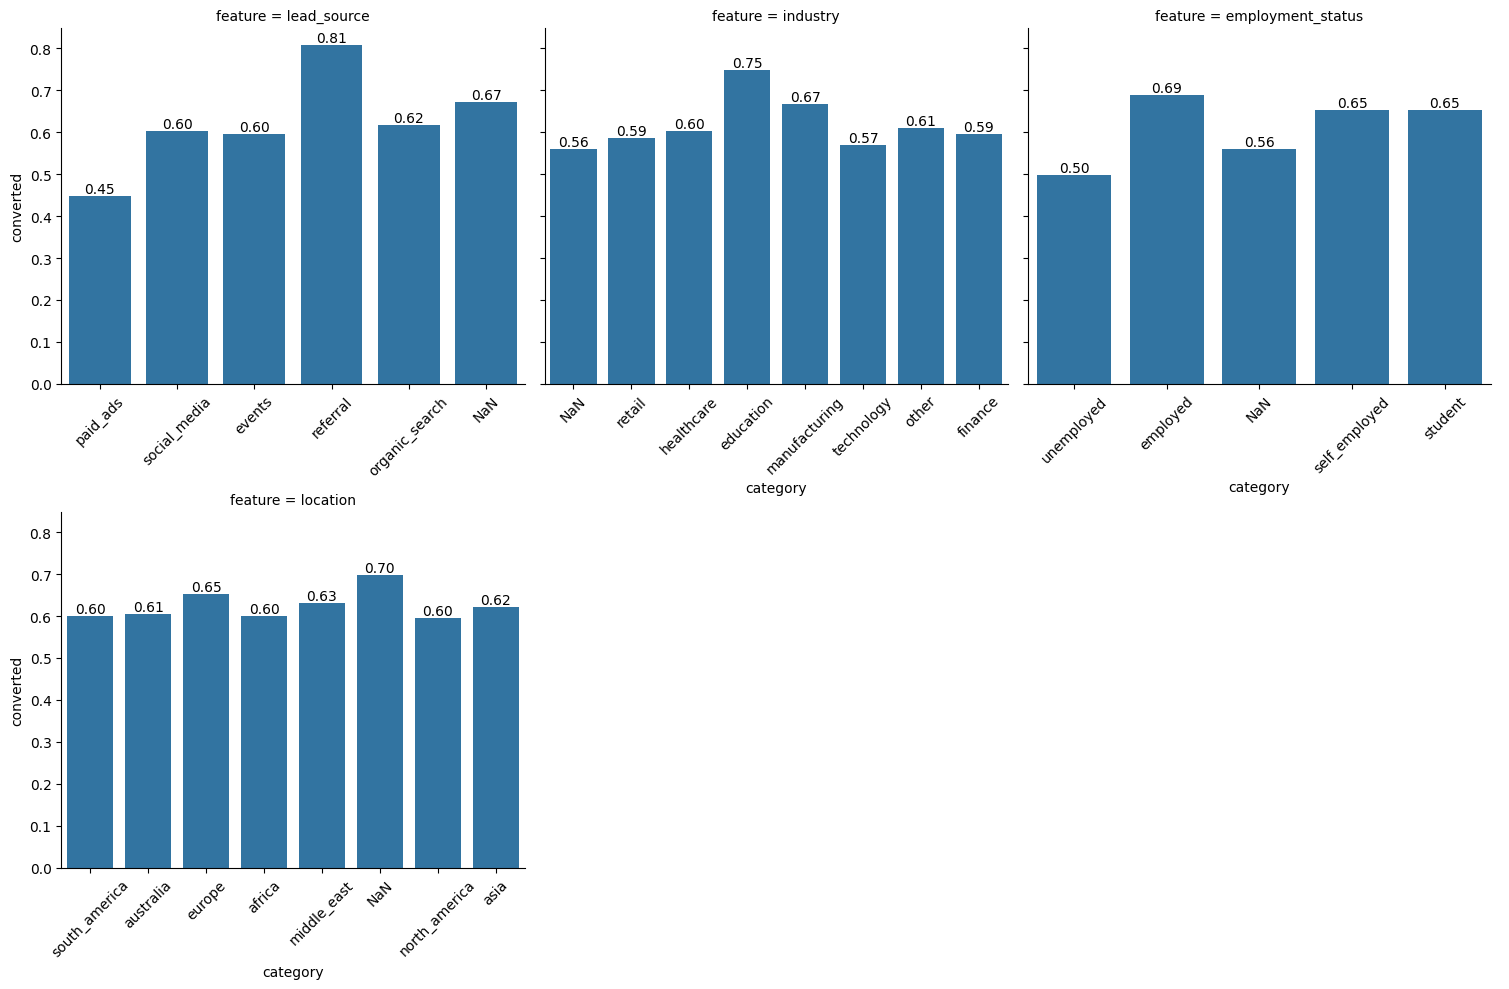

In [47]:
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_long,
    x="category",
    y="converted",
    col="feature",
    kind="bar",
    col_wrap=3,
    errorbar=None,
    sharey=True,
    sharex=False
)

for ax in g.axes.flatten():
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

+ So this kind of visualization allows us to **which specific values** in the categorical variables are **churn drivers**

We see that people that came in from **paid_ads** are much likely to stay over people that came in through **referrals** which are more likely to leave.
In a similar fashion, people belonging to the **education** sector are much likely to leave.

#### Let's also use **risk** ratios to see how much more likely to churn specific groups are

In [48]:
from IPython.display import display

global_churn = df.converted.mean()

for c in categorical_cols:
    print(c)
    print()
    df_group = df.groupby(c).converted.agg(['mean', 'count'])
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    

lead_source



,mean,count,risk
lead_source,,,
NaN,0.671875,128,1.085394
events,0.596000,250,0.962820
organic_search,0.617021,282,0.996779
paid_ads,0.446970,264,0.722066
referral,0.807692,260,1.304802
social_media,0.604317,278,0.976255



industry



,mean,count,risk
industry,,,
NaN,0.559701,134,0.904181
education,0.748663,187,1.209442
finance,0.595000,200,0.961204
healthcare,0.604278,187,0.976193
manufacturing,0.666667,174,1.076980
other,0.611111,198,0.987231
retail,0.586207,203,0.946999
technology,0.569832,179,0.920547



employment_status



,mean,count,risk
employment_status,,,
NaN,0.560000,100,0.904663
employed,0.689024,328,1.113098
self_employed,0.653409,352,1.055563
student,0.652299,348,1.053769
unemployed,0.497006,334,0.802898



location



,mean,count,risk
location,,,
NaN,0.698413,63,1.128264
africa,0.601064,188,0.971000
asia,0.620513,195,1.002420
australia,0.605405,185,0.978014
europe,0.652778,216,1.054543
middle_east,0.631313,198,1.019867
north_america,0.595556,225,0.962102
south_america,0.598958,192,0.967599


### Some clear-cut takeaways we can discern from looking at these tables:

##### As we saw earlier in `lead_source`:
+ People who came through **paid_ads** are much less likely to leave. (0.72)
+ Reverse scenario for people that came by **referral** (1.3).
##### Only **education** comes off as a clear indicator of churn in `industry`.
##### In `emplyoment_status` **unemployed** are less likely to churn over **employed**.
##### Clients that didn't fill out their location (**NaN**) are a bit more likely to leave.


### Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset.
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- `interaction_count` and `lead_score`
- `number_of_courses_viewed` and `lead_score`
- `number_of_courses_viewed` and `interaction_count`
- `annual_income` and `interaction_count`

Only consider the pairs above when answering this question.

In [49]:
corr_matrix=[]
for n in numerical_cols:
    corr_matrix.append(df[numerical_cols].corrwith(df[n]))
    
corr_matrix

[number_of_courses_viewed    1.000000
 annual_income               0.009770
 interaction_count          -0.023565
 lead_score                 -0.004879
 dtype: float64,
 number_of_courses_viewed    0.009770
 annual_income               1.000000
 interaction_count           0.027036
 lead_score                  0.015610
 dtype: float64,
 number_of_courses_viewed   -0.023565
 annual_income               0.027036
 interaction_count           1.000000
 lead_score                  0.009888
 dtype: float64,
 number_of_courses_viewed   -0.004879
 annual_income               0.015610
 interaction_count           0.009888
 lead_score                  1.000000
 dtype: float64]

+ The two best features of the pairs proposed are: **`number_of_courses_viewed`** and **`interaction_count`**

### Split the data

- Split your data in train/val/test sets with 60%/20%/20% distribution.
- Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
- Make sure that the target value `converted` is not in your dataframe.

#### Let's split the data as instructed


In [50]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 42)

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 42)

len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [51]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 3

- Calculate the mutual information score between `converted` and other categorical variables in the dataset. Use the training set only.
- Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?

- `industry`
- `location`
- `lead_source`
- `employment_status`

In [52]:
from sklearn.metrics import mutual_info_score

In [53]:
def mutual_info_churn_score(series):
    return mutual_info_score(series,df_full_train.converted)

In [55]:
round(df_full_train[categorical_cols].apply(mutual_info_churn_score),2)

lead_source          0.03
industry             0.01
employment_status    0.01
location             0.00
dtype: float64

+ `lead_source` ***leads*** in mutual information score

### Question 4

- Now let's train a logistic regression.
- Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
- Fit the model on the training dataset.
  - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
  - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
- Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.64
- 0.74
- 0.84
- 0.94

#### 1. One-hot encoding